# Email Classification: Ham, Spam, and Phishing

This notebook implements a machine learning pipeline to classify emails into **Ham** (legitimate), **Spam** (unsolicited), and **Phishing** (malicious). The dataset combines two sources: a spam/ham dataset and a phishing email dataset, resulting in an imbalanced distribution (4825 Ham, 747 Spam, 189 Phishing). We use SMOTE to balance the classes, TF-IDF for feature extraction, and XGBoost for classification, with plans to fine-tune the model and explore adversarial training.

## Objectives
- Preprocess and combine datasets into a unified format.
- Balance classes using SMOTE and visualize the distribution.
- Train and evaluate an XGBoost classifier.
- Test predictions on sample emails.
- Fine-tune the model and add adversarial training for robustness.

## Dataset
- **Sources**:
  - Spam/Ham: `/kaggle/input/email-spam-detection-dataset-classification/spam.csv`
  - Phishing: `/kaggle/input/phishing/PhishingEmailData.csv`
- **Classes**: Ham (0), Spam (1), Phishing (2)
- **Initial Distribution**: Ham: 4825, Spam: 747, Phishing: 189
- **Post-SMOTE**: 4825 samples per class (total: 14475)

## Pipeline
1. **Data Loading and Preprocessing**: Combine datasets, clean text, and assign labels.
2. **Vectorization**: Convert text to TF-IDF features.
3. **Balancing**: Apply SMOTE to address class imbalance.
4. **Visualization**: Plot class distribution before and after SMOTE.
5. **Training**: Train an XGBoost classifier.
6. **Evaluation**: Assess performance using precision, recall, and F1-score.
7. **Predictions**: Classify new emails and estimate probabilities.
8. **Fine-Tuning**: Optimize XGBoost hyperparameters.
9. **Adversarial Training**: Add adversarial examples for robustness.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/phishing/PhishingEmailData.csv
/kaggle/input/email-spam-detection-dataset-classification/spam.csv


# Loading Dataset

In [8]:
pip install chardet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import chardet

def detect_encoding(file_path):
    with open(file_path, 'rb') as file:
        result = chardet.detect(file.read())
    return result['encoding']

file_path = '/kaggle/input/phishing/PhishingEmailData.csv'
encoding = detect_encoding(file_path)
print(f"Detected encoding: {encoding}")

# Use the detected encoding to read the file
phish_df = pd.read_csv(file_path, encoding=encoding)

Detected encoding: MacRoman


In [11]:
# Try reading the phishing dataset with a different encoding
 
file_path2='/kaggle/input/email-spam-detection-dataset-classification/spam.csv'
encoding = detect_encoding(file_path)
print(f"Detected encoding: {encoding}")

# Use the detected encoding to read the file
spam_df = pd.read_csv(file_path2, encoding=encoding)


Detected encoding: MacRoman


In [13]:
phish_df.sample(5)

,Email_Subject,Email_Content,Sending_Date,Sending_Time,Day,URL_Title,Coined.Word,Sender_Name,Sender_Title,Closing_Remarks,Sender_Email,Logo,To
120,[Important] Login Review On Kent Users,microsoft password review,"April 2nd, 2019",12.53pm,tue,confirm now,"account, confirm, verification, interruptiom",Y,Y,na,Y,Microsoft,B
186,Re: Payment Invoice,please check your,"February 12th, 2019",2.17am EST,na,na,"invoice, payment",Y,Y,Thank you,Y,na,B
188,We recieved your request,request to deactivate,"January 29th, 2019",2.11pm,tue,cancel,"request, cancel, deactivate,",Y,Y,na,Y,offcie 365,B
80,Business/Partnership,deal and interest in business,"May 10th, 2019",1.13am,fri,na,benefits,Y,Y,Sincerely,Y,na,B
31,IMPORTANT TAX RETURN DOCUMENT AVAILABLE,"Dear: Account Owner,\n\nOur records indicate t...",1/6/16,5:53:32 AM,NaN,Click Here,"TAX, W2, important",na,NaN,na,ESSW2@berkeley.edu,na,NB


In [12]:
spam_df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
580,ham,Huh so early.. Then Ã_ having dinner outside i...,NaN,NaN,NaN
280,ham,You got called a tool?,NaN,NaN,NaN
2635,ham,Tiwary to rcb.battle between bang and kochi.,NaN,NaN,NaN
4417,ham,"When you get free, call me",NaN,NaN,NaN
3054,spam,EASTENDERS TV Quiz. What FLOWER does DOT compa...,NaN,NaN,NaN


# Data Cleaning

In [14]:
phish_df.drop(columns=['Logo', 'Coined.Word', 'Sender_Title', 'To','Sending_Date','Sending_Time','Day','Sender_Name','Sender_Email','Closing_Remarks'], inplace=True, errors='ignore')
phish_df['text'] = phish_df['Email_Subject'].fillna('') + ' ' + phish_df['Email_Content'].fillna('') + phish_df['URL_Title'].fillna('')
phish_df = phish_df[phish_df['text'].str.strip().astype(bool)]



In [19]:
phish_df['label'] = 2

In [22]:
 
phish_df.drop(columns=['Email_Subject', 'Email_Content', 'URL_Title','Sender_Email '], inplace=True, errors='ignore')


In [21]:
phish_df.columns

Index(['Sender_Email ', 'text', 'label'], dtype='object')

In [23]:
phish_df.sample(5)

,text,label
118,March Statement - Kent payroll has been submi...,2
125,New fax from: Fax Service.... new faxfead your...,2
132,RE: QUOTE STATEMENT Please confirm if quoting...,2
92,"Kent Validation Request on May 01, 2019, 03:00...",2
23,Google Docs Download You have a pending incomi...,2


In [24]:
spam_df = spam_df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})

# Map labels: spam = 1, ham = 0
spam_df['label'] = spam_df['label'].map({'spam': 1, 'ham': 0})

# Remove rows with missing or empty text
spam_df = spam_df[spam_df['text'].str.strip().astype(bool)]

In [36]:
 combined_df = pd.concat([phish_df[['text', 'label']], spam_df[['text', 'label']]], ignore_index=True)


In [39]:
 combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [44]:
combined_df.sample(5)

,text,label
1126,Dear Email User Your password will expire in 2...,2
510,I've been barred from all B and Q stores for l...,0
3625,Hello my little party animal! I just thought I...,0
4822,Ok no problem... Yup i'm going to sch at 4 if ...,0
3034,Am i that much bad to avoid like this?,0


In [48]:
import re
import string
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\d+", "", text)  # remove numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()  # remove extra whitespace
    return text
combined_df['text'] = combined_df['text'].apply(clean_text)

# Data Visualizations

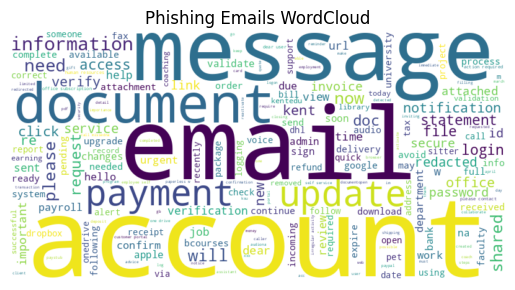

In [67]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(combined_df[combined_df['label'] == 2]['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Phishing Emails WordCloud")
plt.show()


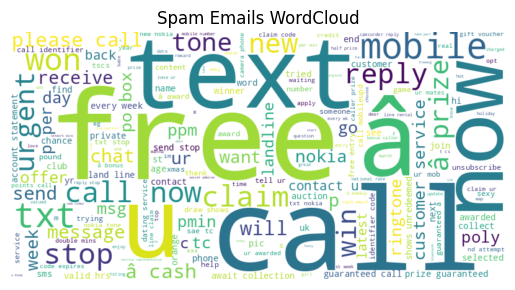

In [68]:
from wordcloud import WordCloud

text = " ".join(combined_df[combined_df['label'] == 1]['text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Spam Emails WordCloud")
plt.show()


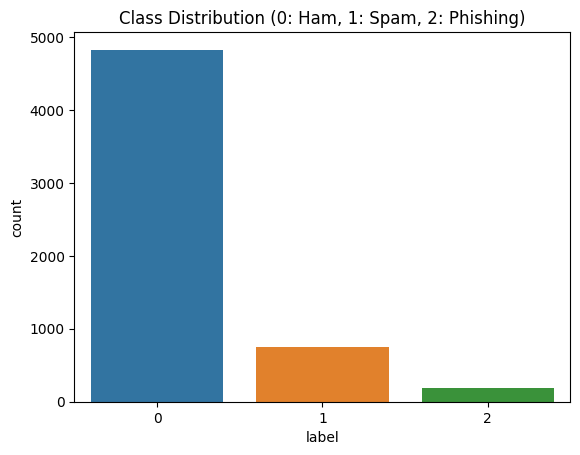

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=combined_df)
plt.title("Class Distribution (0: Ham, 1: Spam, 2: Phishing)")
plt.show()


In [46]:
print(combined_df['label'].value_counts())

label
0    4825
1     747
2     189
Name: count, dtype: int64


# Data Balancing using SMOTE

In [59]:
!pip install -U scikit-learn==1.2.2 imbalanced-learn==0.10.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 5.2 MB/s eta 0:00:0000:01
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0


In [60]:
 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

 
 


In [62]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(combined_df['text']).toarray()  # Convert to dense
y = combined_df['label']


In [63]:
from collections import Counter

print("Before SMOTE:", Counter(y))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After SMOTE:", Counter(y_resampled))


Before SMOTE: Counter({0: 4825, 1: 747, 2: 189})
After SMOTE: Counter({0: 4825, 1: 4825, 2: 4825})


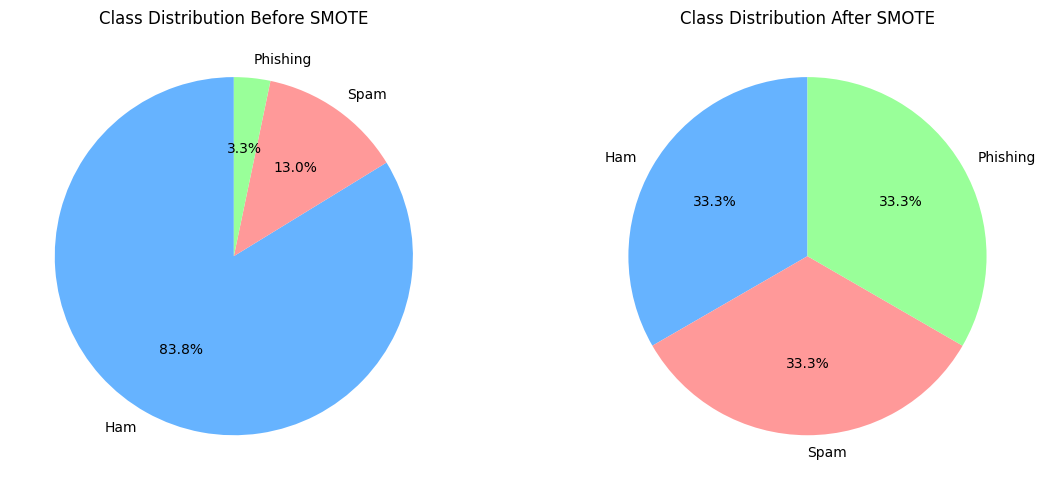

In [70]:
import matplotlib.pyplot as plt
from collections import Counter

 
before_smote = Counter({0: 4825, 1: 747, 2: 189})
after_smote = Counter({0: 4825, 1: 4825, 2: 4825})

 
labels = ['Ham', 'Spam', 'Phishing']
before_counts = [before_smote[0], before_smote[1], before_smote[2]]
after_counts = [after_smote[0], after_smote[1], after_smote[2]]
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
 
ax1.pie(before_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999', '#99ff99'])
ax1.set_title('Class Distribution Before SMOTE')

 
ax2.pie(after_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999', '#99ff99'])
ax2.set_title('Class Distribution After SMOTE')
 
ax1.set_aspect('equal')
ax2.set_aspect('equal')

# Display the plot
plt.tight_layout()
plt.show()

# Data Splitting & Model Training

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)


In [71]:
print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)
print("Training Class Distribution:", Counter(y_train))
print("Test Class Distribution:", Counter(y_test))

Training Set Shape: (11580, 5000)
Test Set Shape: (2895, 5000)
Training Class Distribution: Counter({2: 3860, 0: 3860, 1: 3860})
Test Class Distribution: Counter({0: 965, 1: 965, 2: 965})


In [72]:
# Initialize and train XGBoost
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
model.fit(X_train, y_train)

print("Training Complete!")

Training Complete!


# Evaluation

In [73]:
# Predict on test set
y_pred = model.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam", "Phishing"]))

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       965
        Spam       0.99      0.99      0.99       965
    Phishing       1.00      1.00      1.00       965

    accuracy                           0.99      2895
   macro avg       0.99      0.99      0.99      2895
weighted avg       0.99      0.99      0.99      2895



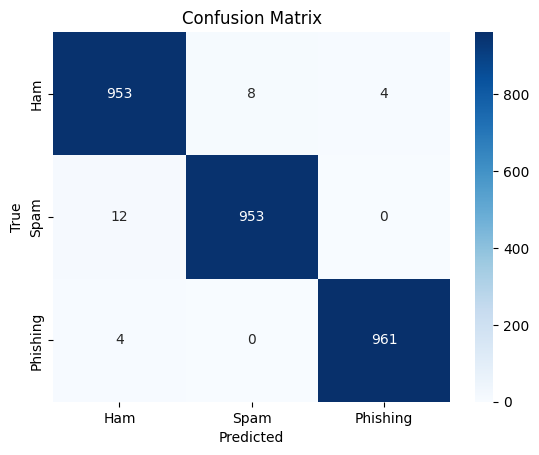

In [74]:
 

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam', 'Phishing'], yticklabels=['Ham', 'Spam', 'Phishing'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# Predictions

In [75]:
def preprocess_email(text):
    # Optional: Add text cleaning (e.g., lowercasing, remove punctuation)
    clean = text.lower()  # Basic cleaning
    return vectorizer.transform([clean]).toarray()  # Return dense array

def predict_email_category(email_text):
    vec = preprocess_email(email_text)
    pred = model.predict(vec)[0]
    return ["Ham", "Spam", "Phishing"][pred]





In [80]:
# Example prediction
sample_email = "Congratulations! You've won a free iPhone. Click here to claim your prize now!"
print("Prediction:", predict_email_category(sample_email))

Prediction: Spam


In [82]:
# Example prediction
sample_email = "Dear student, your timetable for the new semester is available on the portal"
print("Prediction:", predict_email_category(sample_email))

Prediction: Ham


In [83]:
# Example prediction
sample_email = "Your PayPal account has been suspended. Please verify your identity immediately by clicking this link"
print("Prediction:", predict_email_category(sample_email))

Prediction: Phishing


# Save the Trained Model

In [86]:
import joblib

# Save the trained XGBoost model
joblib.dump(model, 'email_classifier_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


# Probabilities of Prediction

In [75]:
def predict_email_probabilities(email_text):
    # Clean and vectorize the email
    clean = preprocess_email(email_text)  # this should match your original cleaning logic
    vec = vectorizer.transform([clean])
    
    # Predict class probabilities
    probs = model.predict_proba(vec)[0]
    
    # Map class labels
    class_labels = ["Ham", "Spam", "Phishing"]
    
    # Create a dictionary of class: probability
    prob_dict = {label: round(prob, 4) for label, prob in zip(class_labels, probs)}
    
    return prob_dict


In [ ]:
email = "plan"
print(predict_email_probabilities(email))


In [85]:
sample_emails = [
 
    "Hi John, just checking in to see if you're available for the meeting tomorrow at 3 PM.",
    "Dear student, your timetable for the new semester is available on the portal.",

 
    "Congratulations! You've won a free iPhone. Click here to claim your prize now!",
    "Lowest mortgage rates available! Apply now and save thousands!",

 
    "Your PayPal account has been suspended. Please verify your identity immediately by clicking this link.",
    "Important: We detected unusual activity in your bank account. Log in now to secure it."
]

 

